# PCA Coursework Template

**Module:** COMP2870 Theoretical Foundations of Computer Science II

**Assignment:** PCA & Data Exploration using Gram–Schmidt QR

**Instructions:** Follow each task in order. Do not change the names or signatures of the three functions that are autograded**: `normalise_dataset`, `covariance`, and `sorted_eigenvalues`. You may add helper functions/cells as needed.

> Use only your own implementations (and the provided `solvers.py`) for PCA—do not call `numpy.linalg.eig` / `numpy.linalg.eigh` / `sklearn` for eigen computations.

In [44]:
import numpy as np
import pandas as pd
import solvers
import matplotlib.pyplot as plt

## Important: solvers.py Interface

The provided `solvers.gram_schmidt_eigen` function has the following interface:

```python
solvers.gram_schmidt_eigen(A, max_iterations=1000, tolerance=1e-10)
```

**Parameters:**
- `A`: Symmetric square matrix of shape (n, n)
- `max_iterations`: Maximum number of QR iterations (default: 1000)
- `tolerance`: Convergence threshold (default: 1e-10)

**Returns:**
- `eigenvalues`: 1D numpy array of length n (**unsorted**)
- `eigenvectors`: 2D numpy array of shape (n, n) where `eigenvectors[:, i]` is the eigenvector corresponding to `eigenvalues[i]`

## 1. Load and prepare data

You will be given three options (boardgames / spotify / coffee). Point `DATASET_PATH` at **one** of them.

In [45]:
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# Set the path to the dataset you are using.
# Examples: 'boardgame_data.csv', 'spotify.csv', 'coffee.csv'
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
DATASET_PATH = "coffee_data.csv"  # change as needed

# Load
df = pd.read_csv(DATASET_PATH)
print("Loaded:", DATASET_PATH)
display(df.head())
print(df.info())

Loaded: coffee_data.csv


,Country_of_Origin,Harvest_Year,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Moisture,farm_altitude_mean_meters,Total_Cup_Points
0,Haiti,2012,6.75,6.58,6.42,6.67,7.08,6.67,9.33,6.0,6.0,6.42,0.14,464.5152,67.92
1,Mexico,2012,7.08,6.83,6.25,7.42,7.25,6.75,10.00,0.0,10.0,6.75,0.11,900.0000,68.33
2,Honduras,2014,7.00,6.17,6.17,6.67,6.50,6.17,8.00,8.0,8.0,6.50,0.10,1450.0000,69.17
3,Honduras,2014,7.00,6.33,6.17,6.50,6.67,6.17,8.00,8.0,8.0,6.33,0.10,1450.0000,69.17
4,Honduras,2014,6.67,6.50,6.17,6.67,6.83,6.17,8.00,8.0,8.0,6.33,0.10,1450.0000,69.33


<class 'pandas.DataFrame'>
RangeIndex: 1088 entries, 0 to 1087
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country_of_Origin          1088 non-null   str    
 1   Harvest_Year               1088 non-null   int64  
 2   Aroma                      1088 non-null   float64
 3   Flavor                     1088 non-null   float64
 4   Aftertaste                 1088 non-null   float64
 5   Acidity                    1088 non-null   float64
 6   Body                       1088 non-null   float64
 7   Balance                    1088 non-null   float64
 8   Uniformity                 1088 non-null   float64
 9   Clean_Cup                  1088 non-null   float64
 10  Sweetness                  1088 non-null   float64
 11  Cupper_Points              1088 non-null   float64
 12  Moisture                   1088 non-null   float64
 13  farm_altitude_mean_meters  1088 non-null   float64
 14  Tot

Create a DataFrame `numeric_df` with only numeric columns. Decide and document how you handle missing values (e.g., drop rows with any NaNs).

In [46]:
# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number]).copy()
n_sample_points, n_attributes = numeric_df.shape
numeric_df = numeric_df.dropna()

print("Numeric shape:", numeric_df.shape)
display(numeric_df.head())

Numeric shape: (1088, 14)


,Harvest_Year,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Moisture,farm_altitude_mean_meters,Total_Cup_Points
0,2012,6.75,6.58,6.42,6.67,7.08,6.67,9.33,6.0,6.0,6.42,0.14,464.5152,67.92
1,2012,7.08,6.83,6.25,7.42,7.25,6.75,10.00,0.0,10.0,6.75,0.11,900.0000,68.33
2,2014,7.00,6.17,6.17,6.67,6.50,6.17,8.00,8.0,8.0,6.50,0.10,1450.0000,69.17
3,2014,7.00,6.33,6.17,6.50,6.67,6.17,8.00,8.0,8.0,6.33,0.10,1450.0000,69.17
4,2014,6.67,6.50,6.17,6.67,6.83,6.17,8.00,8.0,8.0,6.33,0.10,1450.0000,69.33


## 2. Visualise data

Plot histograms for all numeric columns.
Briefly comment on any skewness, multi-modality, or outliers you observe.

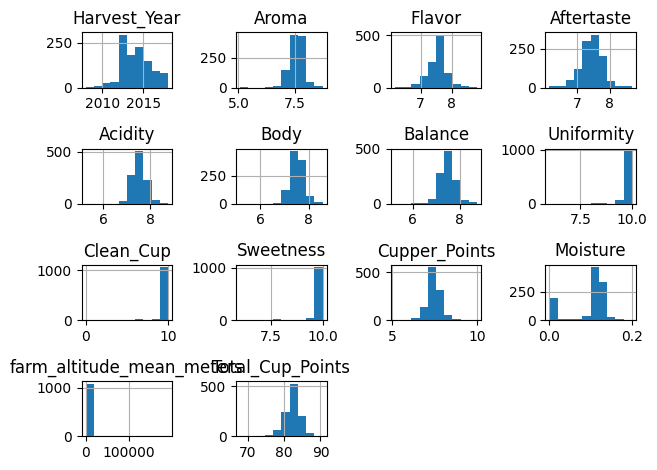

In [47]:
numeric_df.hist()
plt.tight_layout()

### Commentary

_TODO Write your observations on the histograms here. Suggested word limit: 50 words_

Some Icon looks normal, Like Aroma, Flavor. But the Uniformity, Clean_Cup and Sweetness are mostly concentrate to 10. The changes are small and may be have a few outliers.

## 3. Write a function to normalise the dataset

Implement: `normalise_dataset` (autograded)

Standardise attributes to zero mean and unit variance. Return the normalised array and the per-attributes mean and std. Do not change the function name or signature.

In [48]:
def normalise_dataset(X):
    """
    Standardise the dataset attribute-wise to zero mean and unit variance.

    Parameters
    ----------
    X : np.ndarray
        2D array of shape (n_sample_points, n_attributes).

    Returns
    -------
    X_norm : np.ndarray
        Normalised data with zero mean and unit variance per attribute.
        Shape: (n_sample_points, n_attributes).
    mu : np.ndarray
        Attribute means. Shape: (n_attributes,).
    sigma : np.ndarray
        Attribute standard deviations. Shape: (n_attributes,).

    Notes
    -----
    * Compute mu as the mean of each column
    * Compute sigma as the standard deviation along each column
    * For attributes where sigma == 0 (constant attributes), set the normalized
      values to zero.
    * Do not use external ML libraries (sklearn, etc.).
    """
    # TODO: implement
    # compute mean of each column
    mu = np.mean(X, axis=0)

    # compute standard deviation of each column
    sigma = np.std(X, axis=0)

    # normalise
    X_norm = (X - mu) / sigma

    # handle constant columns (std = 0)
    X_norm[:, sigma == 0] = 0

    return X_norm, mu, sigma
    raise NotImplementedError

## 4. Covariance analysis

Implement the `covariance` function and visualise the covariance matrix. Comment on any strong positive/negative relationships.

In [49]:
def covariance(X: np.ndarray) -> np.ndarray:
    """
    Compute the sample covariance matrix. You should not assume that the data is normalised in this function.

    Parameters
    ----------
    X : np.ndarray
        2D array of shape (n_sample_points, n_attributes).

    Returns
    -------
    np.ndarray
        Covariance matrix of shape (n_attributes, n_attributes).
        Element (i, j) represents the covariance between attributes i and j.

    Notes
    -----
    * The resulting matrix should be symmetric: C[i,j] == C[j,i].
    * Do not use numpy.cov() or other pre-built covariance functions.
    """
    # TODO: implement
    # number of samples
    n = X.shape[0]

    # compute mean of each column
    mu = np.mean(X, axis=0)

    # center the data
    X_centered = X - mu

    # compute covariance matrix
    C = (X_centered.T @ X_centered) / (n - 1)

    return C
    raise NotImplementedError

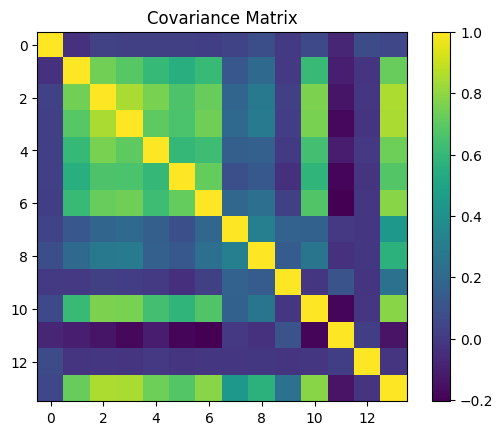

Ellipsis

In [50]:
# Prepare a numpy array for covariance / PCA
X = numeric_df.values.astype(float)

# Compute covariance
X_std, _, _ = normalise_dataset(X)
C = covariance(X_std)

# Visualise covariance as a heatmap
# TODO implement
plt.imshow(C)
plt.colorbar()
plt.title("Covariance Matrix")
plt.show()
# HINT https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
...

### Commentary
_TODO Interpret the covariance heatmap. Which attributes co-vary strongly? Any surprising patterns? Suggested word limit: 50 words_

In the chart, We can see there is a cluster of features which aree strong related. Because they are shows by the brighter colours. The variables seem increase together. And the others are weaker relationships.

## 5. Eigenvalues and eigenvectors computations

Compute the eigenvalues and eigenvectors using the Gram–Schmidt QR method (from `solvers.py`)
Implement `sorted_eigenvalues` to (a) compute eigenpairs using `solvers.gram_schmidt_eigen`, and (b) sort them by **decreasing eigenvalue**.

In [51]:
def sorted_eigenvalues(A):
    """
    Compute eigenvalues and eigenvectors of A using the Gram–Schmidt QR
    algorithm, then sort them by decreasing eigenvalue.

    Parameters
    ----------
    A : np.ndarray
        A symmetric square matrix of shape (n, n).
        Typically this will be a covariance matrix.

    Returns
    -------
    eigenvalues : np.ndarray
        1D array of length n containing eigenvalues sorted in descending order.
    eigenvectors : np.ndarray
        2D array of shape (n, n) where column i (eigenvectors[:, i]) is the
        normalized eigenvector corresponding to eigenvalues[i].
        Eigenvectors are sorted to match the order of eigenvalues.

    Notes
    -----
    * Use solvers.gram_schmidt_eigen(A) to compute the eigendecomposition.
      This function returns (eigenvalues, eigenvectors, iterations).
      You only need the first two return values.
    * The function MODIFIES the input matrix A in place, so always pass A.copy().
    * The returned eigenvalues and eigenvectors are UNSORTED.
    * Sort the eigenvalues in descending order (largest first).
    * Reorder the eigenvector columns to match the sorted eigenvalue order.
    * Do not use numpy.linalg.eig, numpy.linalg.eigh, or similar functions.

    Example
    -------
    If A has eigenvalues [2.5, 5.1, 1.3], this function should return:
        eigenvalues = [5.1, 2.5, 1.3]
        eigenvectors[:, 0] corresponds to eigenvalue 5.1
        eigenvectors[:, 1] corresponds to eigenvalue 2.5
        eigenvectors[:, 2] corresponds to eigenvalue 1.3
    """
    # TODO: implement
    # use a copy because the solver changes the matrix
    eigenvalues, eigenvectors, _ = solvers.gram_schmidt_eigen(A.copy())

    # sort eigenvalues from largest to smallest
    order = np.argsort(eigenvalues)[::-1]

    # reorder both eigenvalues and eigenvectors
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    return eigenvalues, eigenvectors
    raise NotImplementedError

In [52]:
# TODO Compute eigenvalues and eigenvectors of covariance and print first 5 eigenvalues
# compute eigenvalues and eigenvectors of covariance matrix
eigenvalues, eigenvectors = sorted_eigenvalues(C)

# print first 5 eigenvalues
print("First 5 eigenvalues:")
print(eigenvalues[:5])

First 5 eigenvalues:
[6.17898691 1.47884205 1.11587916 1.00649723 0.86690816]


## 6. Check orthonormality

Verify that the matrix of eigenvectors, $S$, satisfies $S^T S \approx I_n$. Report the maximum absolute deviation from the identity.

In [53]:
# TODO implement test of orthonormality
# test orthonormality
S = eigenvectors

# compute S^T S
check_matrix = S.T @ S

# identity matrix of the same size
I = np.eye(check_matrix.shape[0])

# maximum absolute difference from identity
max_dev = np.max(np.abs(check_matrix - I))

print("S^T S =")
print(check_matrix)

print("Maximum absolute deviation from identity:")
print(max_dev)

S^T S =
[[ 1.00000000e+00 -6.15647712e-18  8.62195058e-16 -3.18319758e-17
   6.06553218e-16 -3.46442882e-16  1.01868073e-16  6.68580173e-16
   4.44089210e-16 -1.66533454e-16  1.63757896e-15  3.05311332e-16
   9.48516261e-16  1.05337127e-11]
 [-6.15647712e-18  1.00000000e+00 -1.00338633e-15 -4.21885182e-16
  -5.06641123e-17  1.08054854e-15  5.64044694e-16  6.36686710e-16
   1.11022302e-16 -2.49800181e-16  1.61676228e-15 -4.02455846e-16
   1.63831025e-16 -6.12440932e-12]
 [ 8.62195058e-16 -1.00338633e-15  1.00000000e+00  1.16667332e-16
  -1.33063504e-15 -2.19635838e-16  2.17825817e-16  2.09114733e-16
   8.74300632e-16 -1.52655666e-16  9.12464548e-16 -9.02056208e-17
   6.66420634e-16 -1.11832042e-12]
 [-3.18319758e-17 -4.21885182e-16  1.16667332e-16  1.00000000e+00
   1.90001316e-16 -3.19195554e-17 -1.25222636e-17 -4.71455168e-16
  -2.70616862e-16  2.22044605e-16 -8.03176969e-16 -2.77555756e-17
   3.43684633e-16  1.29392430e-12]
 [ 6.06553218e-16 -5.06641123e-17 -1.33063504e-15  1.9000131

## 7. Explained variance

Plot the variance explained by each principal component and the cumulative curve. Comment on how many components capture most variance.

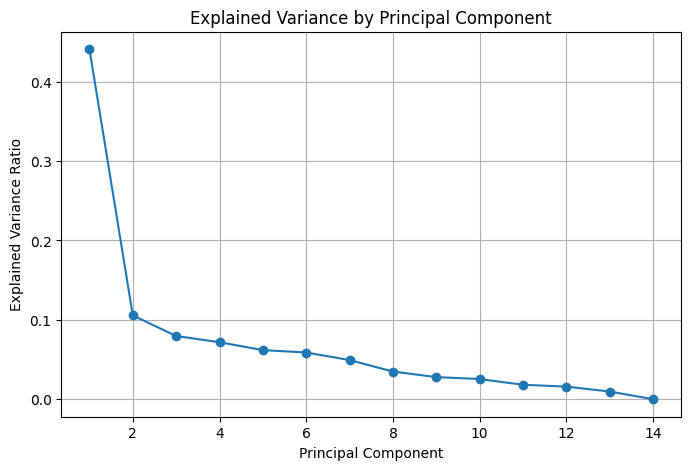

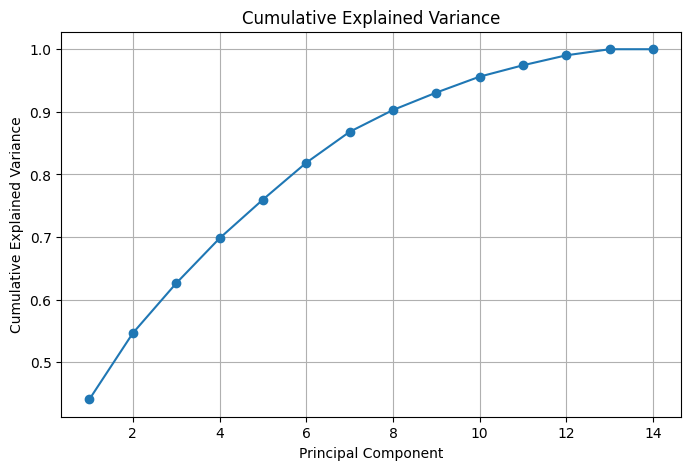

In [54]:
# TODO plot of cummulative explained variance
# explained variance ratio
explained_variance = eigenvalues / np.sum(eigenvalues)

# cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance)

# plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")
plt.grid(True)
plt.show()

# plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

### Commentary
_TODO How many components would you retain and why? Suggested word limit: 50 words._

I will remain 8 components. Because 8 components are nearly 90%, It retaining most of the information and reduce the dimension. If less than 8, too much information will lost, If addd, the improvement will become small.

## 8. Projection

Project dataset onto just first two principal components (eigenvectors) plot PC1 vs PC2. Use the same centring/normalisation choice you used for covariance.

Create a scatter plot of PC1 vs PC2 and colour by an interesting attribute from the dataset.
Comment on clusters/patterns/outliers.

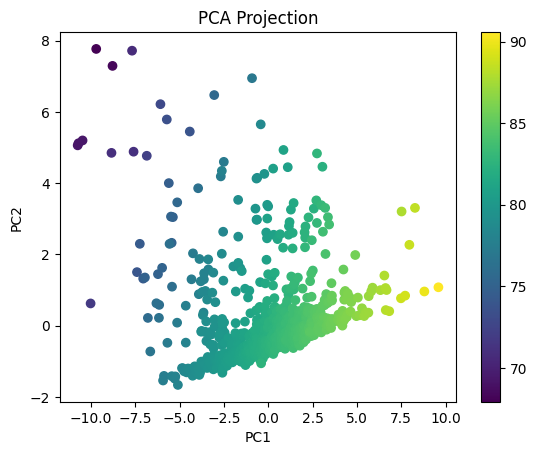

In [55]:
# TODO plot of PC1 vs PC2 coloured by interesting attribute
# take the first two principal components
S = eigenvectors[:, :2]

# project the data onto 2D space
X_proj = X_std @ S

# choose a column for colouring (can change if needed)
color = numeric_df["Total_Cup_Points"]

# plot the scatter
plt.figure()
plt.scatter(X_proj[:, 0], X_proj[:, 1], c=color)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.colorbar()
plt.show()

### Commentary
TODO _Describe any clusters, trends, or separations you see in PC space. What might drive them?_(Suggested word limit: 50 words)_

The data point are scattered, It not obvious. There is a trend of  better from left to right , because the colourt on the right are brighter. some points are faoaway.